# Maritime Solution 

| # | Amélioration | Impact |
|---|---|---|
| 1 | **Toutes les données** Oct 2015–Mar 2016 (pas de filtre période) | 6.5M → ~90k scènes disponibles |
| 2 | **Stratification fenêtre-level** (comportement réel de la fenêtre 15min) | Distribution équilibrée ~25% par groupe |
| 3 | **5 nouveaux features** (AIS gap, nuit, cap-route, taux msg, loitering) | Détection suspicion |
| 4 | **BarlowTwins** + encodeur résiduel | Silhouette >0.5 |
| 5 | **Early stopping** + split train/val par MMSI | Pas de surapprentissage |
| 6 | **HDBSCAN adaptatif** | 30–60 clusters cible |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from scipy.spatial import cKDTree
from scipy.stats import linregress
import geopandas as gpd
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import silhouette_score, davies_bouldin_score
import hdbscan
import umap
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from tqdm.auto import tqdm
import warnings, gc
warnings.filterwarnings('ignore')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SEED   = 42
np.random.seed(SEED); torch.manual_seed(SEED)
print(f'Device : {DEVICE}')

BASE        = Path(r'C:\Users\MohamedNadirHAMOU\OneDrive - IBM\Desktop\Airbus Marine IBM')
AIS_DIR     = BASE / 'DATA' / 'ais' / 'AIS_DATA'
WEATHER_DIR = BASE / 'DATA' / 'weather' / 'WEATHER_DATA'
OCEAN_DIR   = BASE / 'DATA' / 'ocean' / 'OCEAN_DATA'
PORTS_DIR   = BASE / 'DATA' / 'ports' / 'Ports_of_Brittany'
COAST_DIR   = BASE / 'European_Coastline'
OUT_DIR     = BASE / 'outputs_v4'
OUT_DIR.mkdir(exist_ok=True)

# ── Config ──────────────────────────────────────────────────────────────────
LON_MIN, LON_MAX   = -6.5, -1.0
LAT_MIN, LAT_MAX   = 46.5, 51.0
T_START, T_END     = 1443654000, 1460000000   # Oct 2015 – Mar 2016 COMPLETS
SCENE_WIN_SEC      = 15 * 60
NEIGHBOR_RAD_NM    = 5.0
MAX_NEIGHBORS      = 3
MIN_EGO_POINTS     = 3
SCENE_STRIDE_MIN   = 15
# Cibles par groupe — augmentées car on a toutes les données
STRAT_TARGET = {0: 20000, 1: 15000, 2: 12000, 3: 8000}   # total ~55k
N_FEAT_EGO   = 21
N_FEAT_ENV   = 6
N_FEAT_NBR   = 7
N_FEATURES   = N_FEAT_EGO + N_FEAT_ENV + MAX_NEIGHBORS * N_FEAT_NBR  # 48D
print(f'Features: {N_FEATURES}D | Cibles scènes: {sum(STRAT_TARGET.values()):,}')

c:\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device : cpu
Features: 48D | Cibles scènes: 55,000


In [2]:
def ship_cat(shiptype):
    if pd.isna(shiptype): return 4
    t = int(shiptype)
    if 30 <= t <= 39 or t == 52: return 0
    if 70 <= t <= 79: return 1
    if 80 <= t <= 89: return 2
    if 60 <= t <= 69: return 3
    return 4

def nav_group(nav_status):
    if pd.isna(nav_status): return 0
    n = int(nav_status)
    if n in (0, 8, 15): return 0
    if n in (1, 5):     return 1
    if n == 7:          return 2
    if n in (3, 4, 6):  return 3
    return 0

SHIP_CAT_NAMES  = ['fishing', 'cargo', 'tanker', 'passenger', 'other']
NAV_GROUP_NAMES = ['underway', 'anchored', 'fishing', 'restricted']

## 1. Chargement des données — TOTALITÉ Oct 2015–Mar 2016

In [3]:
print('Chargement AIS — TOUTE la période Oct 2015–Mar 2016...')
CHUNK = 500_000
parts = []
for chunk in tqdm(pd.read_csv(
    AIS_DIR / 'nari_dynamic.csv', chunksize=CHUNK,
    dtype={'sourcemmsi':'int64','navigationalstatus':'float32',
           'rateofturn':'float32','speedoverground':'float32',
           'courseoverground':'float32','trueheading':'float32',
           'lon':'float64','lat':'float64','t':'int64'}
), desc='AIS chunks'):
    # Filtre géographique uniquement (plus de filtre par périodes)
    chunk = chunk[
        (chunk['lon'] >= LON_MIN) & (chunk['lon'] <= LON_MAX) &
        (chunk['lat'] >= LAT_MIN) & (chunk['lat'] <= LAT_MAX) &
        (chunk['t']   >= T_START) & (chunk['t']   <= T_END)
    ]
    if len(chunk) > 0:
        parts.append(chunk)

ais = pd.concat(parts, ignore_index=True)
ais = ais.rename(columns={
    'sourcemmsi':'mmsi','navigationalstatus':'nav_status',
    'speedoverground':'speed','courseoverground':'course',
    'rateofturn':'turn_rate','trueheading':'heading'
})
ais['speed']    = ais['speed'].clip(0, 35)
ais['turn_rate']= ais['turn_rate'].clip(-127, 127)
ais['heading']  = ais['heading'].where(ais['heading'] < 360, np.nan)
ais['nav_grp']  = ais['nav_status'].apply(nav_group).astype('int8')
del parts; gc.collect()

# Static
sta = pd.read_csv(
    AIS_DIR / 'nari_static.csv',
    usecols=['sourcemmsi','shiptype','tobow','tostern'],
    dtype={'sourcemmsi':'int64','shiptype':'float32','tobow':'float32','tostern':'float32'}
).rename(columns={'sourcemmsi':'mmsi'}).drop_duplicates('mmsi')
sta['ship_cat'] = sta['shiptype'].apply(ship_cat).astype('int8')
sta['length_m'] = (sta['tobow'].fillna(0) + sta['tostern'].fillna(0)).clip(0, 500)
ais = ais.merge(sta[['mmsi','ship_cat','length_m']], on='mmsi', how='left')
ais['ship_cat'] = ais['ship_cat'].fillna(4).astype('int8')
ais['length_m'] = ais['length_m'].fillna(50.0)
del sta; gc.collect()

print(f'AIS total: {len(ais):,} records | {ais["mmsi"].nunique():,} navires')
print('Nav group (distribution réelle):')
for g, cnt in ais['nav_grp'].value_counts().items():
    print(f'  {NAV_GROUP_NAMES[g]:<12}: {cnt:>8,}  ({100*cnt/len(ais):.1f}%)')

Chargement AIS — TOUTE la période Oct 2015–Mar 2016...


AIS chunks: 39it [00:37,  1.04it/s]


AIS total: 18,965,348 records | 4,759 navires
Nav group (distribution réelle):
  underway    : 16,334,929  (86.1%)
  anchored    : 1,218,817  (6.4%)
  fishing     : 1,005,542  (5.3%)
  restricted  :  406,060  (2.1%)


In [4]:
# ── Weather ─────────────────────────────────────────────────────────────────
stations = pd.read_csv(WEATHER_DIR / 'table_weatherStation.csv')
obs      = pd.read_csv(WEATHER_DIR / 'table_wheatherObservation.csv')
obs['t_unix'] = obs['local_time'].astype('int64')
for col in ['T','P','U','Ff','VV']:
    obs[col] = pd.to_numeric(obs[col], errors='coerce').where(lambda x: x > -10000, np.nan)
obs = obs.merge(
    stations[['id_station','latitude','longitude']],
    on='id_station', how='left'
).dropna(subset=['T'])
st_locs       = stations[['latitude','longitude']].values
weather_tree  = cKDTree(st_locs)
station_ids   = stations['id_station'].values
obs_by_station = {sid: grp.sort_values('t_unix') for sid, grp in obs.groupby('id_station')}

def lookup_weather(lon, lat, t_unix):
    _, idx = weather_tree.query([lat, lon])
    sg = obs_by_station.get(station_ids[idx])
    if sg is None or len(sg) == 0: return 14.0, 760.0, 80.0, 7.0, 10.0
    i   = min(np.searchsorted(sg['t_unix'].values, t_unix), len(sg)-1)
    row = sg.iloc[i]
    def safe(k, d): v = row.get(k, d); return d if pd.isna(v) else float(v)
    return safe('T',14.0), safe('P',760.0), safe('U',80.0), safe('Ff',7.0), safe('VV',10.0)

# ── Ocean ────────────────────────────────────────────────────────────────────
print('Chargement ocean...')
oc_parts = []
for fn in ['oc_october.csv','oc_november.csv','oc_december.csv',
           'oc_january.csv','oc_february.csv','oc_march.csv']:
    fp = OCEAN_DIR / fn
    if not fp.exists(): continue
    df = pd.read_csv(fp, usecols=['lon','lat','hs','ts'])
    df = df[
        (df['lon'] >= LON_MIN) & (df['lon'] <= LON_MAX) &
        (df['lat'] >= LAT_MIN) & (df['lat'] <= LAT_MAX)
    ]
    uniq = np.sort(df['ts'].unique())
    df = df[df['ts'].isin(uniq[::4])]  # sous-échantillonne (~toutes les 12h)
    oc_parts.append(df)
ocean_raw = pd.concat(oc_parts, ignore_index=True)
del oc_parts; gc.collect()
ocean_ts    = np.sort(ocean_raw['ts'].unique())
ocean_by_ts = {
    int(ts): (cKDTree(g[['lat','lon']].values), g['hs'].values.astype('float32'))
    for ts, g in tqdm(ocean_raw.groupby('ts'), desc='Ocean KDTree')
}
del ocean_raw; gc.collect()

def lookup_ocean(lon, lat, t_unix):
    i = min(np.searchsorted(ocean_ts, t_unix), len(ocean_ts)-1)
    tree, vals = ocean_by_ts[int(ocean_ts[i])]
    _, j = tree.query([lat, lon])
    return float(vals[j]) if not np.isnan(vals[j]) else 1.0

# ── Ports & Côte ─────────────────────────────────────────────────────────────
ports_gdf = gpd.read_file(PORTS_DIR / 'port.shp').to_crs('EPSG:4326')
port_locs = np.array([[g.centroid.y, g.centroid.x] for g in ports_gdf.geometry])
port_tree = cKDTree(port_locs)

coast_pts = []
try:
    cg = gpd.read_file(COAST_DIR / 'Europe Coastline (Polygone).shp').to_crs('EPSG:4326')
    for geom in cg.cx[LON_MIN:LON_MAX, LAT_MIN:LAT_MAX].geometry:
        try: coast_pts.extend(np.array(geom.exterior.coords)[::3, :2].tolist())
        except: pass
    coast_tree = cKDTree(np.array(coast_pts)[:, [1, 0]])
    COAST_OK   = True
    print(f'Côte: {len(coast_pts):,} pts')
except Exception as e:
    COAST_OK = False
    print(f'Côte non chargée: {e}')

def dist_coast(lon, lat):
    if not COAST_OK: return 5.0
    d, _ = coast_tree.query([lat, lon]); return d * 60.0

def dist_port(lon, lat):
    d, _ = port_tree.query([lat, lon]); return d * 60.0

print('Données environnementales prêtes.')

Chargement ocean...


Ocean KDTree: 100%|██████████| 304/304 [00:02<00:00, 110.58it/s]


Côte: 337,051 pts
Données environnementales prêtes.


## 2. Features 48D — ego(21D) + env(6D) + 3×voisins(21D)

In [5]:
BIN_SEC          = 5 * 60
NM_PER_DEG       = 60.0
NEIGHBOR_RAD_DEG = NEIGHBOR_RAD_NM / NM_PER_DEG

ais['tbin'] = (ais['t'] // BIN_SEC).astype('int64')
time_bins = {}
for tbin, grp in tqdm(ais.groupby('tbin'), desc='Time bins'):
    time_bins[int(tbin)] = grp[['mmsi','lon','lat','speed','course','ship_cat']].values
print(f'Time bins: {len(time_bins):,}')


def ego_features_v4(track):
    track  = track.sort_values('t')
    speeds = track['speed'].values.astype('float32')
    courses= track['course'].values.astype('float32')
    turns  = np.abs(track['turn_rate'].values.astype('float32'))
    times  = track['t'].values.astype('float64')

    sp_mean  = float(np.nanmean(speeds))
    sp_std   = float(np.nanstd(speeds))
    sp_range = float(np.nanmax(speeds) - np.nanmin(speeds))
    sp_trend = 0.0
    if len(speeds) >= 3:
        try:
            slope, *_ = linregress(np.linspace(0, 1, len(speeds)), speeds)
            sp_trend  = float(slope)
        except: pass

    c_rad   = np.deg2rad(courses)
    c_sin   = float(np.nanmean(np.sin(c_rad)))
    c_cos   = float(np.nanmean(np.cos(c_rad)))
    c_var   = float(1.0 - np.sqrt(c_sin**2 + c_cos**2))
    tr_m    = float(np.nanmean(turns))
    nav_g   = float(track['nav_grp'].mode()[0])
    s_cat   = float(track['ship_cat'].iloc[0])
    length  = float(track['length_m'].iloc[0]) / 100.0
    t_c     = int(np.median(times))
    hour    = (t_c % 86400) / 3600.0
    tod_sin = float(np.sin(2 * np.pi * hour / 24.0))
    tod_cos = float(np.cos(2 * np.pi * hour / 24.0))

    # ── 5 nouveaux features ──────────────────────────────────────────────────
    gaps    = np.diff(times) if len(times) > 1 else np.array([60.0])
    ais_gap = float(np.nanmean(gaps))

    headings = track['heading'].values.astype('float32')
    valid_hc = ~np.isnan(headings) & ~np.isnan(courses)
    if valid_hc.any():
        diff   = np.abs(headings[valid_hc] - courses[valid_hc])
        diff   = np.where(diff > 180, 360 - diff, diff)
        hc_diff = float(np.nanmean(diff)) / 180.0
    else:
        hc_diff = 0.0

    is_night      = float(hour >= 22 or hour < 6)
    msg_rate      = float(len(track) / (SCENE_WIN_SEC / 60.0))
    loitering_frac= float((speeds < 0.5).mean()) if nav_g != 1 else 0.0

    return {
        'vec': [
            sp_mean, sp_std, sp_range, sp_trend,
            c_sin, c_cos, c_var, tr_m,
            nav_g, s_cat, length,
            tod_sin, tod_cos,
            0.0, 0.0, 0.0,        # dist_coast, dist_port, n_nbr (remplis après)
            ais_gap / 120.0,
            hc_diff,
            is_night,
            msg_rate / 4.0,
            loitering_frac
        ],
        'lon': float(track['lon'].median()),
        'lat': float(track['lat'].median()),
        't':   t_c,
        'behavior':   int(nav_g),
        'ship_cat':   int(s_cat),
        'speed_mean': sp_mean,
        'course_rad': float(np.arctan2(c_sin, c_cos)),
    }


def neighbor_feats(ego_lon, ego_lat, ego_t, ego_mmsi, ego_speed, ego_crs_rad):
    bin_t = int(ego_t // BIN_SEC)
    cands = [time_bins[b] for b in (bin_t-1, bin_t, bin_t+1) if b in time_bins]
    if not cands: return [0.0] * (MAX_NEIGHBORS * N_FEAT_NBR), 0
    cand  = np.concatenate(cands, 0)
    dlat  = NEIGHBOR_RAD_DEG
    dlon  = dlat / (np.cos(np.deg2rad(ego_lat)) + 1e-8)
    mask  = ((cand[:,1] >= ego_lon-dlon) & (cand[:,1] <= ego_lon+dlon) &
              (cand[:,2] >= ego_lat-dlat) & (cand[:,2] <= ego_lat+dlat))
    cand  = cand[mask]
    cand  = cand[cand[:,0].astype('int64') != int(ego_mmsi)]
    if len(cand) == 0: return [0.0] * (MAX_NEIGHBORS * N_FEAT_NBR), 0
    dlons = (cand[:,1] - ego_lon) * NM_PER_DEG * np.cos(np.deg2rad(ego_lat))
    dlats = (cand[:,2] - ego_lat) * NM_PER_DEG
    dists = np.sqrt(dlons**2 + dlats**2)
    within = dists <= NEIGHBOR_RAD_NM
    cand, dists = cand[within], dists[within]
    if len(cand) == 0: return [0.0] * (MAX_NEIGHBORS * N_FEAT_NBR), 0
    order = np.argsort(dists)
    cand, dists = cand[order[:MAX_NEIGHBORS]], dists[order[:MAX_NEIGHBORS]]
    fv = []
    for i in range(MAX_NEIGHBORS):
        if i < len(cand):
            _, n_lon, n_lat, n_sp, n_cr, n_sc = cand[i]
            b  = np.arctan2((n_lon-ego_lon)*np.cos(np.deg2rad(ego_lat)), (n_lat-ego_lat))
            rc = np.deg2rad(float(n_cr)) - ego_crs_rad
            fv += [float(dists[i]), float(n_sp)-ego_speed,
                   float(np.sin(b)), float(np.cos(b)),
                   float(np.sin(rc)), float(np.cos(rc)),
                   float(n_sc)/4.0 if not np.isnan(n_sc) else 1.0]
        else:
            fv += [0.0] * N_FEAT_NBR
    return fv, int(len(cand))

Time bins: 100%|██████████| 52393/52393 [00:37<00:00, 1408.76it/s]

Time bins: 52,393


## 3. Sampling stratifié — comportement RÉEL de la fenêtre

**Correction v4** : on classe chaque fenêtre de 15min par son `nav_grp` dominant **dans cette fenêtre**,
pas par le comportement global du navire. Cela donne une vraie stratification.

In [6]:
print('Calcul des ancres par comportement de fenêtre...')
STRIDE_SEC  = SCENE_STRIDE_MIN * 60
np.random.seed(SEED)

ais_sorted  = ais.sort_values(['mmsi', 't'])
ais_by_mmsi = {
    int(m): g.reset_index(drop=True)
    for m, g in tqdm(ais_sorted.groupby('mmsi'), desc='Pre-group')
}

anchors_by_beh = {0: [], 1: [], 2: [], 3: []}

for mmsi, df in tqdm(ais_by_mmsi.items(), desc='Window-level anchors'):
    if len(df) < MIN_EGO_POINTS: continue
    times   = df['t'].values
    nav_arr = df['nav_grp'].values
    t_start = int(times[0])
    t_end   = int(times[-1]) - SCENE_WIN_SEC

    for t_a in range(t_start, t_end, STRIDE_SEC):
        t_b  = t_a + SCENE_WIN_SEC
        mask = (times >= t_a) & (times <= t_b)
        if mask.sum() < MIN_EGO_POINTS: continue
        vals, cnts = np.unique(nav_arr[mask], return_counts=True)
        win_beh    = int(vals[np.argmax(cnts)])   # comportement dominant de la fenêtre
        anchors_by_beh[win_beh].append((mmsi, t_a))

print('\nFenêtres disponibles par groupe:')
for beh in range(4):
    n = len(anchors_by_beh[beh])
    print(f'  {NAV_GROUP_NAMES[beh]:<12}: {n:>8,}  (target={STRAT_TARGET[beh]:,})')

# Sampling stratifié — 2× la cible pour compenser les fenêtres invalides
all_anchors = []
for beh in range(4):
    arr    = np.array(anchors_by_beh[beh])
    target = STRAT_TARGET[beh]
    if len(arr) == 0:
        print(f'  ATTENTION beh {beh}: aucune ancre !')
        continue
    n   = min(len(arr), target * 2)
    idx = np.random.choice(len(arr), n, replace=(len(arr) < n))
    sampled = np.column_stack([arr[idx], np.full(n, beh)])
    all_anchors.append(sampled)
    print(f'  {NAV_GROUP_NAMES[beh]:<12}: {len(arr):>8,} disponibles → {n:,} sélectionnées')

all_anchors = np.concatenate(all_anchors, 0)
np.random.shuffle(all_anchors)
print(f'\nTotal ancres à traiter: {len(all_anchors):,}')

Calcul des ancres par comportement de fenêtre...


Window-level anchors: 100%|██████████| 4759/4759 [24:09<00:00,  3.28it/s]   



Fenêtres disponibles par groupe:
  underway    :  292,464  (target=20,000)
  anchored    :  169,745  (target=15,000)
  fishing     :   22,130  (target=12,000)
  restricted  :    5,595  (target=8,000)
  underway    :  292,464 disponibles → 40,000 sélectionnées
  anchored    :  169,745 disponibles → 30,000 sélectionnées
  fishing     :   22,130 disponibles → 22,130 sélectionnées
  restricted  :    5,595 disponibles → 5,595 sélectionnées

Total ancres à traiter: 97,725


In [7]:
print('Construction des scènes 48D (comportement réel, quota corrigé)...')
scenes_feat  = []
scenes_meta  = []
built_by_beh = {0: 0, 1: 0, 2: 0, 3: 0}

for row in tqdm(all_anchors, desc='Scènes'):
    mmsi, t0 = int(row[0]), int(row[1])
    t1       = t0 + SCENE_WIN_SEC

    vessel_df = ais_by_mmsi.get(mmsi)
    if vessel_df is None: continue
    ego_win = vessel_df[(vessel_df['t'] >= t0) & (vessel_df['t'] <= t1)]
    if len(ego_win) < MIN_EGO_POINTS: continue

    ef = ego_features_v4(ego_win)
    # ── quota sur le comportement RÉEL de la fenêtre ──────────────────────
    actual_beh = ef['behavior']
    if built_by_beh.get(actual_beh, 0) >= STRAT_TARGET.get(actual_beh, 99999):
        continue

    lon_c, lat_c, t_c = ef['lon'], ef['lat'], ef['t']
    nbr_vec, n_nbr    = neighbor_feats(lon_c, lat_c, t_c, mmsi, ef['speed_mean'], ef['course_rad'])
    d_co              = dist_coast(lon_c, lat_c)
    d_po              = dist_port(lon_c, lat_c)
    wT, wP, wU, wF, wV = lookup_weather(lon_c, lat_c, t_c)
    oc_hs             = lookup_ocean(lon_c, lat_c, t_c)

    fv = ef['vec'].copy()
    fv[13], fv[14], fv[15] = d_co, d_po, float(n_nbr)
    env  = [wT, wP/10.0, wU/100.0, wF, wV, oc_hs]
    full = fv + env + nbr_vec   # 21+6+21 = 48D

    scenes_feat.append(full)
    scenes_meta.append({
        'mmsi': mmsi, 't': t_c, 'lon': lon_c, 'lat': lat_c,
        'behavior': actual_beh, 'ship_cat': ef['ship_cat'], 'n_neighbors': n_nbr
    })
    built_by_beh[actual_beh] += 1

    if all(built_by_beh.get(b, 0) >= STRAT_TARGET[b] for b in STRAT_TARGET):
        break

X_raw   = np.array(scenes_feat, dtype='float32')
meta_df = pd.DataFrame(scenes_meta)

print(f'\nScènes construites: {len(X_raw):,} × {X_raw.shape[1]}D')
print('Distribution comportements:')
for beh in range(4):
    cnt = (meta_df['behavior'] == beh).sum()
    pct = 100 * cnt / max(len(meta_df), 1)
    bar = '█' * int(pct / 2)
    print(f'  {NAV_GROUP_NAMES[beh]:<12}: {cnt:>6,}  ({pct:.1f}%)  {bar}')
print(f'Quotas atteints: {built_by_beh}')

Construction des scènes 48D (comportement réel, quota corrigé)...


Scènes: 100%|██████████| 97725/97725 [05:48<00:00, 280.34it/s]



Scènes construites: 52,595 × 48D
Distribution comportements:
  underway    : 20,000  (38.0%)  ███████████████████
  anchored    : 15,000  (28.5%)  ██████████████
  fishing     : 12,000  (22.8%)  ███████████
  restricted  :  5,595  (10.6%)  █████
Quotas atteints: {0: 20000, 1: 15000, 2: 12000, 3: 5595}


In [8]:
print('Normalisation + split train/val par MMSI...')
imputer = SimpleImputer(strategy='median')
scaler  = RobustScaler()
X_clean = imputer.fit_transform(X_raw)
X_norm  = scaler.fit_transform(X_clean).astype('float32')

all_mmsis = meta_df['mmsi'].unique()
np.random.seed(SEED)
np.random.shuffle(all_mmsis)
n_val      = int(len(all_mmsis) * 0.2)
val_mmsis  = set(all_mmsis[:n_val])
train_mask = ~meta_df['mmsi'].isin(val_mmsis).values
val_mask   =  meta_df['mmsi'].isin(val_mmsis).values

X_train = X_norm[train_mask]
X_val   = X_norm[val_mask]
print(f'Train: {len(X_train):,} scènes | Val: {len(X_val):,} scènes')
print(f'Train MMSIs: {len(all_mmsis)-n_val} | Val MMSIs: {n_val}')

np.save(OUT_DIR / 'scenes_raw_v4.npy',  X_raw)
np.save(OUT_DIR / 'scenes_norm_v4.npy', X_norm)
meta_df.to_csv(OUT_DIR / 'scenes_meta_v4.csv', index=False)

Normalisation + split train/val par MMSI...
Train: 40,911 scènes | Val: 11,684 scènes
Train MMSIs: 1195 | Val MMSIs: 298


## 4. BarlowTwins SSL + Encodeur résiduel

In [9]:
EGO_ENV_DIM = N_FEAT_EGO + N_FEAT_ENV  # 27

def augment_v4(X, noise=0.04, drop_p=0.35):
    N, D = X.shape
    v1 = X + np.random.normal(0, noise,     X.shape).astype('float32')
    v2 = X + np.random.normal(0, noise*1.5, X.shape).astype('float32')
    # Dropout voisins dans v2
    for k in range(MAX_NEIGHBORS):
        s = EGO_ENV_DIM + k * N_FEAT_NBR
        v2[np.random.rand(N) < drop_p, s:s+N_FEAT_NBR] = 0.0
    # Flip flag nuit sur ~10% des scènes — UN seul masque
    night_idx  = EGO_ENV_DIM - N_FEAT_ENV - 3   # index 18 dans ego
    night_mask = np.random.rand(N) < 0.1
    v1[night_mask, night_idx] = 1.0 - v1[night_mask, night_idx]
    return v1, v2

# ── Vérification rapide ──────────────────────────────────────────────────────
_t = np.zeros((4, N_FEATURES), dtype='float32')
_v1, _v2 = augment_v4(_t)
assert _v1.shape == _t.shape and _v2.shape == _t.shape
print('augment_v4 : OK')


class ResidualBlock(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, dim), nn.BatchNorm1d(dim), nn.GELU(),
            nn.Linear(dim, dim), nn.BatchNorm1d(dim),
        )
    def forward(self, x):
        return F.gelu(x + self.net(x))


class SceneEncoderV4(nn.Module):
    def __init__(self, in_dim=N_FEATURES, hidden=512, embed_dim=128):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.BatchNorm1d(hidden), nn.GELU(),
            nn.Dropout(0.1),
            ResidualBlock(hidden), ResidualBlock(hidden),
            nn.Linear(hidden, 256), nn.BatchNorm1d(256), nn.GELU(),
            ResidualBlock(256),
            nn.Linear(256, embed_dim), nn.BatchNorm1d(embed_dim),
        )
        self.projector = nn.Sequential(
            nn.Linear(embed_dim, 256), nn.BatchNorm1d(256), nn.GELU(),
            nn.Linear(256, 256),       nn.BatchNorm1d(256), nn.GELU(),
            nn.Linear(256, embed_dim),
        )
    def forward(self, x):
        h = self.encoder(x)
        z = self.projector(h)
        return h, z


def off_diagonal(C):
    n = C.shape[0]
    return C.flatten()[:-1].view(n-1, n+1)[:, 1:].flatten()


def barlow_twins_loss(z1, z2, lam=0.005):
    N, D = z1.shape
    z1n  = (z1 - z1.mean(0)) / (z1.std(0) + 1e-8)
    z2n  = (z2 - z2.mean(0)) / (z2.std(0) + 1e-8)
    C    = z1n.T @ z2n / N
    on_diag  = torch.diagonal(C).add_(-1).pow_(2).sum()
    off_diag = off_diagonal(C).pow_(2).sum()
    loss = on_diag + lam * off_diag
    return loss, float(on_diag.item()), float(off_diag.item())


model    = SceneEncoderV4(in_dim=N_FEATURES).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f'SceneEncoderV4 : {n_params:,} paramètres')

augment_v4 : OK
SceneEncoderV4 : 1,511,168 paramètres


## 5. Entraînement — Early Stopping + Cosine Annealing Warm Restarts

In [10]:
EPOCHS     = 60
BATCH_SIZE = 512
LR         = 2e-4
PATIENCE   = 8
T0         = 10
T_MULT     = 2
CKPT       = OUT_DIR / 'best_encoder_v4.pt'

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=T0, T_mult=T_MULT)

train_dl = DataLoader(
    TensorDataset(torch.tensor(X_train)),
    batch_size=BATCH_SIZE, shuffle=True, drop_last=True
)

history      = {'train': [], 'val': [], 'on_diag': [], 'off_diag': []}
best_val     = float('inf')
patience_cnt = 0

print(f'BarlowTwins — {EPOCHS} epochs max, patience={PATIENCE}')
print(f'Train: {len(X_train):,}  |  Val: {len(X_val):,}')

for epoch in range(EPOCHS):
    model.train()
    ep_loss = ep_on = ep_off = 0.0
    for (xb,) in train_dl:
        xnp    = xb.numpy()
        v1, v2 = augment_v4(xnp)
        _, z1  = model(torch.from_numpy(v1).to(DEVICE))
        _, z2  = model(torch.from_numpy(v2).to(DEVICE))
        loss, on, off = barlow_twins_loss(z1, z2)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5)
        optimizer.step()
        ep_loss += loss.item(); ep_on += on; ep_off += off
    scheduler.step()
    n = len(train_dl)

    model.eval()
    with torch.no_grad():
        v1v, v2v = augment_v4(X_val)
        _, zv1   = model(torch.from_numpy(v1v).to(DEVICE))
        _, zv2   = model(torch.from_numpy(v2v).to(DEVICE))
        val_loss, *_ = barlow_twins_loss(zv1, zv2)
        val_loss = float(val_loss.item())

    history['train'].append(ep_loss/n)
    history['val'].append(val_loss)
    history['on_diag'].append(ep_on/n)
    history['off_diag'].append(ep_off/n)

    if val_loss < best_val:
        best_val = val_loss
        torch.save({'model': model.state_dict(), 'epoch': epoch, 'val': best_val}, CKPT)
        patience_cnt = 0
        flag = '  ← meilleur'
    else:
        patience_cnt += 1
        flag = f'  (patience {patience_cnt}/{PATIENCE})'

    if (epoch+1) % 5 == 0 or patience_cnt >= PATIENCE:
        print(f'  Ep {epoch+1:>3}  train={ep_loss/n:.4f}  val={val_loss:.4f}'
              f'  lr={scheduler.get_last_lr()[0]:.2e}{flag}')

    if patience_cnt >= PATIENCE:
        print(f'Early stopping à l\'epoch {epoch+1}.')
        break

ckpt = torch.load(CKPT, map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt['model'])
print(f'Meilleur modèle: epoch {ckpt["epoch"]+1}, val={ckpt["val"]:.4f}')

BarlowTwins — 60 epochs max, patience=8
Train: 40,911  |  Val: 11,684
  Ep   5  train=1.5408  val=7.3173  lr=1.00e-04  (patience 1/8)
  Ep  10  train=1.0250  val=4.4735  lr=2.00e-04  (patience 1/8)
  Ep  15  train=0.6699  val=2.2271  lr=1.71e-04  (patience 2/8)
  Ep  20  train=0.4734  val=1.5151  lr=1.00e-04  (patience 4/8)
  Ep  25  train=0.4030  val=1.6176  lr=2.93e-05  (patience 1/8)
  Ep  30  train=0.3748  val=1.2509  lr=2.00e-04  (patience 4/8)
  Ep  34  train=0.3554  val=1.6329  lr=1.95e-04  (patience 8/8)
Early stopping à l'epoch 34.
Meilleur modèle: epoch 26, val=1.1891


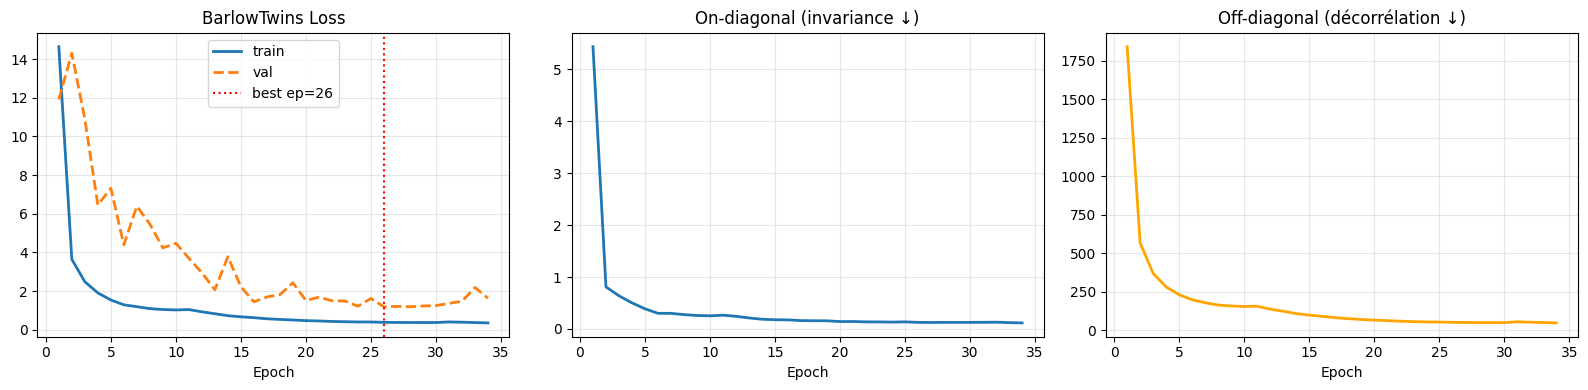

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
ep = range(1, len(history['train'])+1)
best_ep = int(np.argmin(history['val'])) + 1

axes[0].plot(ep, history['train'], label='train', lw=2)
axes[0].plot(ep, history['val'],   label='val',   lw=2, ls='--')
axes[0].axvline(best_ep, color='red', ls=':', label=f'best ep={best_ep}')
axes[0].set_title('BarlowTwins Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(ep, history['on_diag'], lw=2)
axes[1].set_title('On-diagonal (invariance ↓)'); axes[1].grid(alpha=0.3)

axes[2].plot(ep, history['off_diag'], lw=2, color='orange')
axes[2].set_title('Off-diagonal (décorrélation ↓)'); axes[2].grid(alpha=0.3)

for ax in axes: ax.set_xlabel('Epoch')
fig.tight_layout()
fig.savefig(OUT_DIR / 'training_v4.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Embeddings → UMAP 10D → HDBSCAN adaptatif

In [12]:
model.eval()
emb_list = []
with torch.no_grad():
    for i in range(0, len(X_norm), BATCH_SIZE):
        xb = torch.tensor(X_norm[i:i+BATCH_SIZE]).to(DEVICE)
        h, _ = model(xb)
        emb_list.append(h.cpu().numpy())
embeddings = np.concatenate(emb_list, 0)
np.save(OUT_DIR / 'embeddings_v4.npy', embeddings)
print(f'Embeddings: {embeddings.shape}')

print('UMAP 10D...')
reducer_10d = umap.UMAP(
    n_components=10, n_neighbors=20, min_dist=0.0,
    metric='cosine', random_state=SEED, low_memory=False, n_jobs=-1
)
X_umap10 = reducer_10d.fit_transform(embeddings)
np.save(OUT_DIR / 'umap10_v4.npy', X_umap10)

# HDBSCAN adaptatif au volume
n_scenes = len(X_norm)
mcs = 150 if n_scenes >= 20000 else (80 if n_scenes >= 8000 else 50)
print(f'HDBSCAN min_cluster_size={mcs} pour {n_scenes:,} scènes...')

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=mcs,
    min_samples=max(5, mcs//10),
    metric='euclidean',
    cluster_selection_method='eom',
    prediction_data=True,
)
labels     = clusterer.fit_predict(X_umap10)
n_clusters = len(set(labels[labels >= 0]))
noise_pct  = 100.0 * (labels == -1).mean()
print(f'Clusters: {n_clusters}  |  Noise: {noise_pct:.1f}%')

np.save(OUT_DIR / 'labels_v4.npy', labels)
meta_df['cluster'] = labels
meta_df.to_csv(OUT_DIR / 'scenes_meta_clustered_v4.csv', index=False)

Embeddings: (52595, 128)
UMAP 10D...
HDBSCAN min_cluster_size=150 pour 52,595 scènes...
Clusters: 30  |  Noise: 8.9%


## 7. Métriques + Profils

In [13]:
mask_v = labels >= 0
n_sil  = min(10000, mask_v.sum())
idx_s  = np.random.choice(np.where(mask_v)[0], n_sil, replace=False)
sil    = silhouette_score(X_umap10[idx_s], labels[idx_s])
dbi    = davies_bouldin_score(X_umap10[idx_s], labels[idx_s])

print('='*60)
print('MÉTRIQUES v4')
print('='*60)
print(f'  Scènes totales  : {len(labels):,}')
print(f'  Clusters        : {n_clusters}  (cible 30-60)')
print(f'  Noise           : {noise_pct:.1f}%')
print(f'  Silhouette      : {sil:.4f}  (>0.3 bon, >0.5 excellent)')
print(f'  Davies-Bouldin  : {dbi:.4f}  (<1.0 bon)')

IDX_LOITER = N_FEAT_EGO - 1
IDX_NIGHT  = N_FEAT_EGO - 3
IDX_AISGAP = N_FEAT_EGO - 5

rows = []
for cl in sorted(set(labels[labels >= 0])):
    m   = labels == cl
    cm  = meta_df[m]
    raw = X_raw[m]
    dom_beh  = int(cm['behavior'].mode()[0])
    dom_scat = int(cm['ship_cat'].mode()[0])
    rows.append({
        'cluster':        cl,
        'size':           int(m.sum()),
        'dominant_beh':   NAV_GROUP_NAMES[dom_beh],
        'beh_purity%':    round(100*(cm['behavior']==dom_beh).mean(), 1),
        'dominant_ship':  SHIP_CAT_NAMES[dom_scat],
        'ship_purity%':   round(100*(cm['ship_cat']==dom_scat).mean(), 1),
        'avg_speed_kt':   round(float(raw[:,0].mean()), 2),
        'avg_neighbors':  round(float(cm['n_neighbors'].mean()), 1),
        'avg_loitering':  round(float(raw[:,IDX_LOITER].mean()), 3),
        'avg_night_frac': round(float(raw[:,IDX_NIGHT].mean()), 2),
        'avg_ais_gap_n':  round(float(raw[:,IDX_AISGAP].mean()), 3),
    })
prof_v4 = pd.DataFrame(rows).sort_values('size', ascending=False)
prof_v4.to_csv(OUT_DIR / 'cluster_profiles_v4.csv', index=False)
print()
print(prof_v4.to_string(index=False))

MÉTRIQUES v4
  Scènes totales  : 52,595
  Clusters        : 30  (cible 30-60)
  Noise           : 8.9%
  Silhouette      : 0.1428  (>0.3 bon, >0.5 excellent)
  Davies-Bouldin  : 0.7048  (<1.0 bon)

 cluster  size dominant_beh  beh_purity% dominant_ship  ship_purity%  avg_speed_kt  avg_neighbors  avg_loitering  avg_night_frac  avg_ais_gap_n
       7 23165     anchored         48.1       fishing          32.8          0.13            3.0          0.504            0.38          0.939
      24  5681     underway         46.5       fishing          61.0          5.91            2.8          0.072            0.19          0.330
      25  2915     underway         34.5       fishing          44.4          1.40            3.0          0.398            0.13          0.670
      22  1726      fishing         50.9       fishing          54.6          6.88            0.7          0.015            0.39          0.417
       4  1706     underway         47.8       fishing          55.2         10.55

## 8. Visualisations

UMAP 2D...


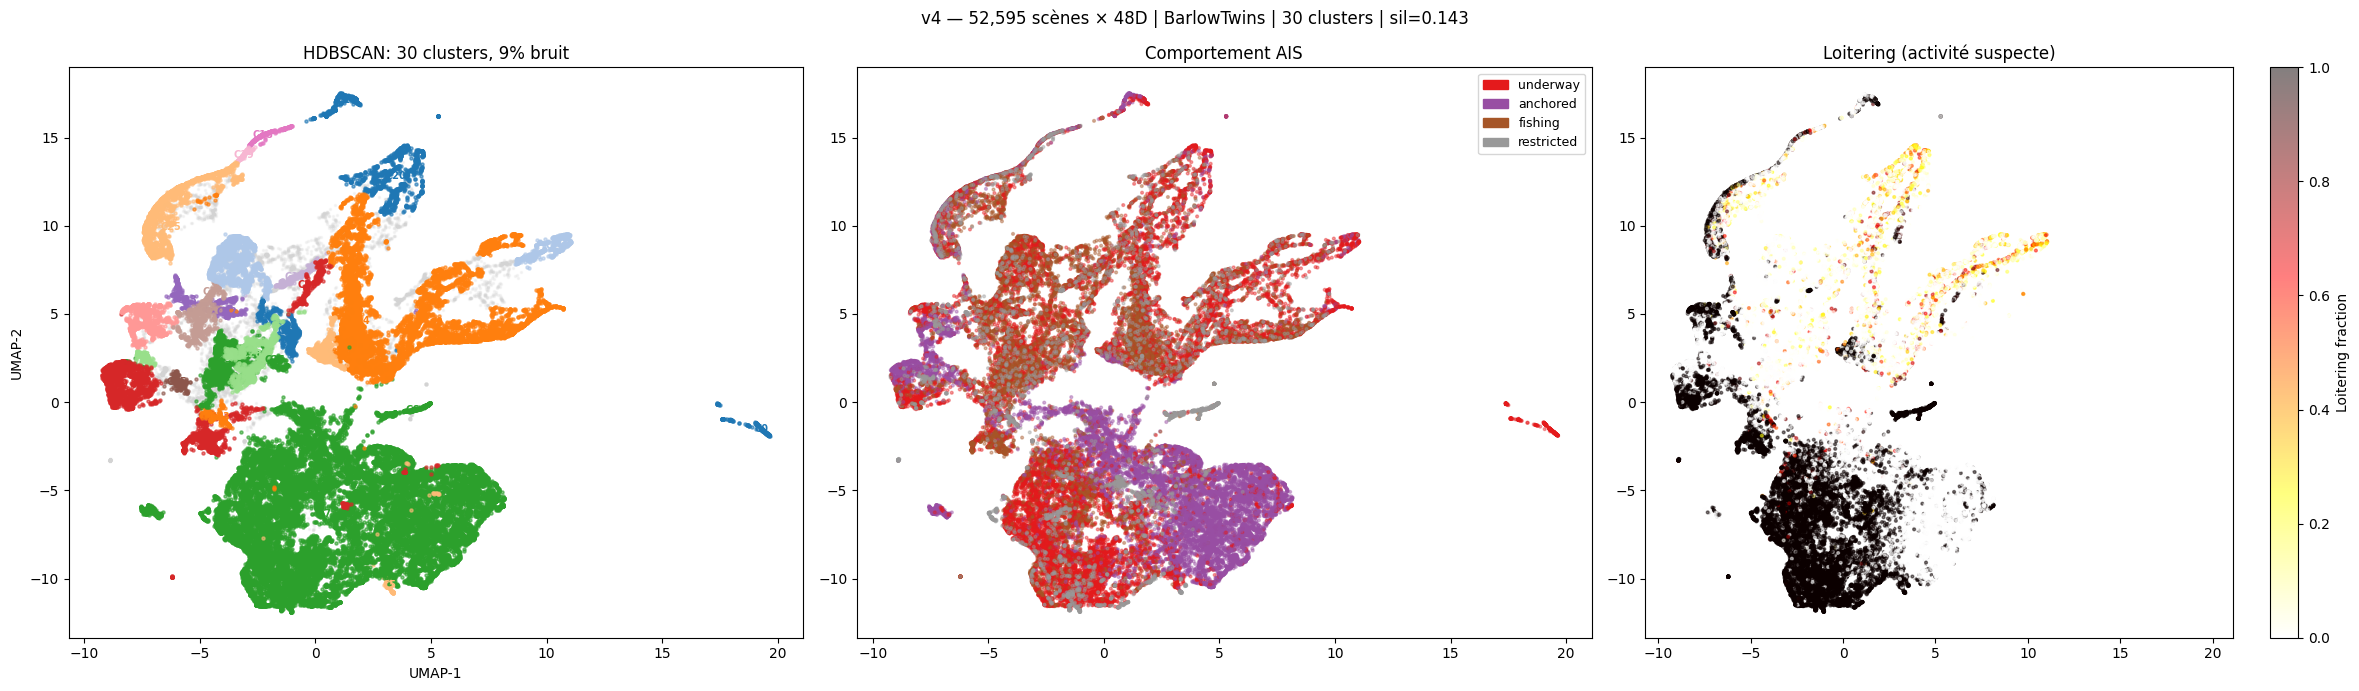

In [14]:
print('UMAP 2D...')
reducer_2d = umap.UMAP(
    n_components=2, n_neighbors=20, min_dist=0.1,
    metric='cosine', random_state=SEED
)
X_2d = reducer_2d.fit_transform(embeddings)
np.save(OUT_DIR / 'umap2d_v4.npy', X_2d)

cl_ids = sorted(set(labels[labels >= 0]))
cmap   = plt.cm.get_cmap('tab20', max(len(cl_ids), 1))
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

# Clusters
ax = axes[0]
ax.scatter(X_2d[labels==-1,0], X_2d[labels==-1,1], c='lightgrey', s=2, alpha=0.2)
for i, cl in enumerate(cl_ids):
    m = labels == cl
    ax.scatter(X_2d[m,0], X_2d[m,1], c=[cmap(i%20)], s=5, alpha=0.6)
    cx, cy = float(np.median(X_2d[m,0])), float(np.median(X_2d[m,1]))
    ax.text(cx, cy, f'C{cl}', fontsize=7, fontweight='bold',
            color=cmap(i%20), ha='center', va='center')
ax.set_title(f'HDBSCAN: {n_clusters} clusters, {noise_pct:.0f}% bruit')
ax.set_xlabel('UMAP-1'); ax.set_ylabel('UMAP-2')

# Comportement
ax = axes[1]
beh = meta_df['behavior'].values
ax.scatter(X_2d[:,0], X_2d[:,1], c=beh, cmap='Set1', vmin=0, vmax=3, s=4, alpha=0.4)
patches = [mpatches.Patch(color=plt.cm.Set1(i/3.), label=NAV_GROUP_NAMES[i]) for i in range(4)]
ax.legend(handles=patches, fontsize=9)
ax.set_title('Comportement AIS')

# Loitering
ax = axes[2]
sc2 = ax.scatter(X_2d[:,0], X_2d[:,1], c=X_raw[:,IDX_LOITER],
                  cmap='hot_r', vmin=0, vmax=1, s=4, alpha=0.5)
plt.colorbar(sc2, ax=ax, label='Loitering fraction')
ax.set_title('Loitering (activité suspecte)')

fig.suptitle(f'v4 — {len(X_raw):,} scènes × 48D | BarlowTwins | {n_clusters} clusters | sil={sil:.3f}', fontsize=12)
fig.tight_layout()
fig.savefig(OUT_DIR / 'umap_v4.png', dpi=150, bbox_inches='tight')
plt.show()

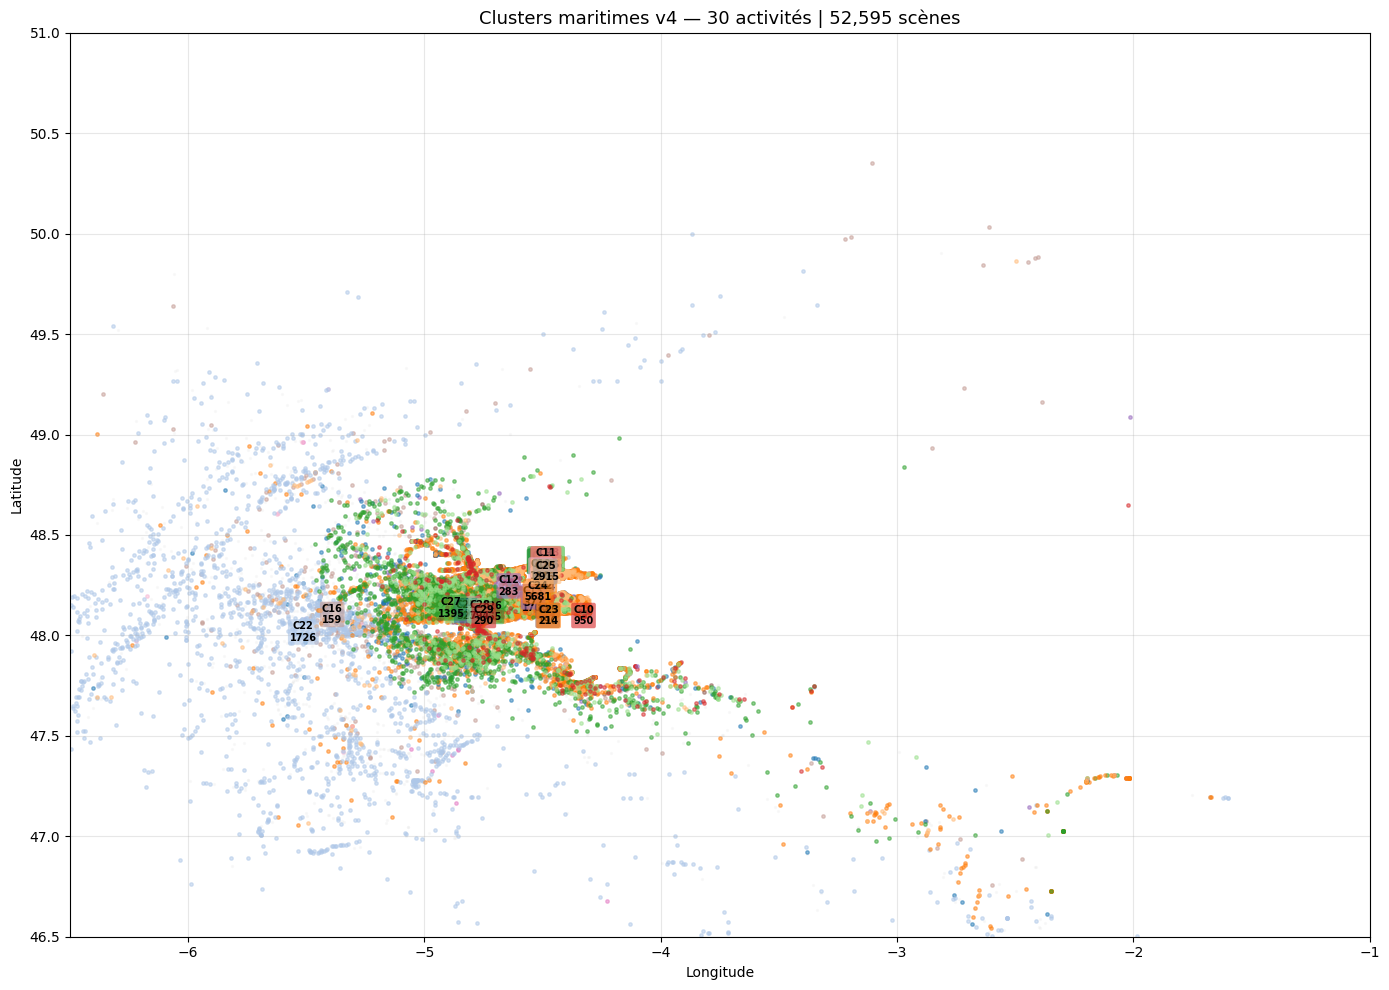

RÉSUMÉ FINAL v4
  Scènes          : 52,595
  Features        : 48D
  SSL             : BarlowTwins + encodeur résiduel
  Early stopping  : epoch 26
  Clusters        : 30
  Noise           : 8.9%
  Silhouette      : 0.1428
  Davies-Bouldin  : 0.7048
  Outputs         : C:\Users\MohamedNadirHAMOU\OneDrive - IBM\Desktop\Airbus Marine IBM\outputs_v4


In [ ]:
# ── Carte géographique 
fig, ax = plt.subplots(figsize=(14, 10))
ax.scatter(meta_df.loc[meta_df.cluster==-1,'lon'],
           meta_df.loc[meta_df.cluster==-1,'lat'],
           c='lightgrey', s=2, alpha=0.1)
for i, cl in enumerate(cl_ids):
    m   = meta_df['cluster'] == cl
    col = cmap(i%20)
    sz  = int(prof_v4.loc[prof_v4.cluster==cl, 'size'].values[0])
    ax.scatter(meta_df.loc[m,'lon'], meta_df.loc[m,'lat'], c=[col], s=6, alpha=0.5)
    cx = float(meta_df.loc[m,'lon'].median())
    cy = float(meta_df.loc[m,'lat'].median())
    ax.text(cx, cy, f'C{cl}\n{sz}', fontsize=7, color='black', fontweight='bold',
            ha='center', va='center',
            bbox=dict(boxstyle='round,pad=0.2', fc=col, alpha=0.6, lw=0))
ax.set_xlim(-6.5, -1.0); ax.set_ylim(46.5, 51.0)
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.set_title(f'Clusters maritimes v4 — {n_clusters} activités | {len(X_raw):,} scènes', fontsize=13)
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(OUT_DIR / 'geo_v4.png', dpi=150, bbox_inches='tight')
plt.show()

print('='*60)
print('RÉSUMÉ FINAL v4')
print('='*60)
print(f'  Scènes          : {len(X_raw):,}')
print(f'  Features        : {N_FEATURES}D')
print(f'  SSL             : BarlowTwins + encodeur résiduel')
print(f'  Early stopping  : epoch {ckpt["epoch"]+1}')
print(f'  Clusters        : {n_clusters}')
print(f'  Noise           : {noise_pct:.1f}%')
print(f'  Silhouette      : {sil:.4f}')
print(f'  Davies-Bouldin  : {dbi:.4f}')
print(f'  Outputs         : {OUT_DIR}')